In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import LineString
import numpy as np
from shapely.ops import split
import matplotlib.patches as patches
from matplotlib.lines import Line2D
from pyfonts import load_google_font

# Df

In [2]:
# Load data
df = pd.read_csv("data.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Occupation  6 non-null      object 
 1   Percentage  6 non-null      float64
dtypes: float64(1), object(1)
memory usage: 228.0+ bytes


In [4]:
df

,Occupation,Percentage
0,Teachers,58.5
1,Ministers,4.3
2,Government Service,3.2
3,Business,2.1
4,Other Professions,3.8
5,House Wives,28.1


In [5]:
# Color dictionary
occupation_color_dict = {
   "Teachers":"#c3002c",  # crimson
   "Ministers":"#6e75a7", # blue
   "Government Service":"#e7c8b8", # pink
   "Business":"#a58867", # brownish
   "Other Professions":"#77765e", # greenish
   "House Wives":"#f3be00" # gold
}

# Apply color mapping
df["color"] = df["Occupation"].map(occupation_color_dict)

In [6]:
# Custom order of occupations
custom_order = ["Teachers", "Ministers", "Business", "Government Service", "Other Professions", "House Wives" ]

# Sorting using the custom order
df["Occupation"] = pd.Categorical(df["Occupation"], categories=custom_order, ordered=True)
sorted_df = df.sort_values("Occupation", ignore_index=True)

In [7]:
sorted_df

,Occupation,Percentage,color
0,Teachers,58.5,#c3002c
1,Ministers,4.3,#6e75a7
2,Business,2.1,#a58867
3,Government Service,3.2,#e7c8b8
4,Other Professions,3.8,#77765e
5,House Wives,28.1,#f3be00


In [8]:
# Create a df for the legend
legend_df = df.copy()

legend_df["Occupation_FR"] = [
    "PROFFESSEURS ET INSTITUTEURS",
    "MINISTRES DE L'EVANGILE",
    "MARCHANDS",
    "EMPLOYÉS DU GOUVERNMENT",    
    "MEDONS, ADVOCATS, ET ÉTUDANTS",
    "MÈRES DE FAMILIE"
]

In [9]:
legend_df

,Occupation,Percentage,color,Occupation_FR
0,Teachers,58.5,#c3002c,PROFFESSEURS ET INSTITUTEURS
1,Ministers,4.3,#6e75a7,MINISTRES DE L'EVANGILE
2,Government Service,3.2,#e7c8b8,MARCHANDS
3,Business,2.1,#a58867,EMPLOYÉS DU GOUVERNMENT
4,Other Professions,3.8,#77765e,"MEDONS, ADVOCATS, ET ÉTUDANTS"
5,House Wives,28.1,#f3be00,MÈRES DE FAMILIE


# Map

In [10]:
# Load shapefile
usa = gpd.read_file("shapefiles/cb_2018_us_state_5m.shp")

In [11]:
usa.head(2)

,STATEFP,STATENS,AFFGEOID,GEOID,STUSPS,NAME,LSAD,ALAND,AWATER,geometry
0,31,01779792,0400000US31,31,NE,Nebraska,00,198956658395,1371829134,"POLYGON ((-104.05351 41.15726, -104.05267 41.2..."
1,53,01779804,0400000US53,53,WA,Washington,00,172112588220,12559278850,"MULTIPOLYGON (((-122.32834 48.02134, -122.3217..."


In [12]:
# Check projection
usa.crs

<Geographic 2D CRS: EPSG:4269>
Name: NAD83
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: North America - onshore and offshore: Canada - Alberta; British Columbia; Manitoba; New Brunswick; Newfoundland and Labrador; Northwest Territories; Nova Scotia; Nunavut; Ontario; Prince Edward Island; Quebec; Saskatchewan; Yukon. Puerto Rico. United States (USA) - Alabama; Alaska; Arizona; Arkansas; California; Colorado; Connecticut; Delaware; Florida; Georgia; Hawaii; Idaho; Illinois; Indiana; Iowa; Kansas; Kentucky; Louisiana; Maine; Maryland; Massachusetts; Michigan; Minnesota; Mississippi; Missouri; Montana; Nebraska; Nevada; New Hampshire; New Jersey; New Mexico; New York; North Carolina; North Dakota; Ohio; Oklahoma; Oregon; Pennsylvania; Rhode Island; South Carolina; South Dakota; Tennessee; Texas; Utah; Vermont; Virginia; Washington; West Virginia; Wisconsin; Wyoming. US Virgin Islands. British Virgin Islands

In [13]:
# Reproject to EPSG:9311
gdf_9311 = usa.to_crs("EPSG:9311")

# List of states to remove
states_to_remove = ["Hawaii", "United States Virgin Islands", "Guam", "Commonwealth of the Northern Mariana Islands",
                    "American Samoa", "Puerto Rico", "Alaska"]
# Filter out states to remove
gdf_9311 = gdf_9311[~gdf_9311["NAME"].isin(states_to_remove)]

In [14]:
# Select Oklahoma
oklahoma = gdf_9311.loc[gdf_9311["NAME"] == "Oklahoma"].iloc[0]

#Extract geometry
poly = oklahoma.geometry

# Bounding box coordinates
minx, miny, maxx, maxy = poly.bounds

# Splitting line
split_line = LineString([
    ((minx + maxx)/1.1, miny - 10000),  
    ((minx + maxx)/1.1, maxy + 10000)
])

# Split the polygon into 2
split_result = split(poly, split_line)

# Remove Oklahoma
gdf_9311 = gdf_9311[gdf_9311["NAME"] != "Oklahoma"]

# New gdf with split geometries
split_gdf = gpd.GeoDataFrame(
    [oklahoma, oklahoma],  
    geometry=list(split_result.geoms),
    crs=gdf_9311.crs
).reset_index(drop=True)

# Rename the two new polygons
split_gdf["STUSPS"] = ["OK1", "OK2"]

# Concatenate original gdf_933 with new gdf
gdf_9311 = gpd.pd.concat([gdf_9311, split_gdf], ignore_index=True)

# Select relevant columns
gdf_9311 = gdf_9311[["NAME", "STUSPS", "geometry"]]

In [15]:
# Function to color states
def states_color_dict(STUSPS):
    if STUSPS in ["WA", "NE", "TX", "WI", "SC", "CT", "NH"]:
        return "#e3c162" # gold 
    elif STUSPS in ["OR", "NM", "IA", "AR", "FL", "NJ", "ME"]:
        return "#9b9b88" # greenish 
    elif STUSPS in ["CA", "CO", "MO", "AL", "DE", "MA"]:
        return "#b92f48"  # crimson 
    elif STUSPS in ["ID", "ND", "OK1", "IN", "WV", "VT"]:  
        return "#ebd2cd" # pink 
    elif STUSPS in ["NV", "MT", "KS", "IL", "NC", "NY"]:
        return "#d5c6b1" # brownish 
    elif STUSPS in ["AZ", "OH", "VA"]:
        return "#afafbe" # lightblue 
    elif STUSPS in ["MN", "MS"]:
        return "#a0a3c3" # blue 
    elif STUSPS in ["WY", "OK2", "MI", "TN", "PA"]:
        return "#2a3377" # darkblue
    elif STUSPS in ["UT", "SD", "LA", "KY", "MD", "DC", "MD", "RI"]:
        return "#6d5b43" # darkbrown 
    else:
        return "#1c1a15" # black
        
# Apply function
gdf_9311["color"] = gdf_9311["STUSPS"].apply(states_color_dict)

# Fonts

In [16]:
# Custom font
font_bold = load_google_font("Public Sans", weight="bold")
font_light = load_google_font("Public Sans", weight="thin")

# Texts

In [17]:
title_black="""
        A SERIES OF STATISTICAL CHARDS, ILLUSTRA-
    TING THE CONDITION OF THE DESCENDANTS OF FOR-
    MER AFRICAN SLAVES NOW RESIDENT IN THE UNITED
    STATES OF AMERICA.
    """

In [18]:
title_red="""
        UNE SÉRIE DE CARTES ET DIAGRAMMES STATISTIQUES MONTRANT LA
    CONDITION PRÉSENTE DES DESCANDANTS DES ANCIENS ESCLAVES AFRI-
    CAINS ACTUELLMENT ÉTABLIS DANS LES ETATS UNIS D'AMERIQUE.
    """

In [19]:
usa_left="""
    PREPARED AND EXECUTED BY
    NEGRO STUDENTS UNDER THE 
    DIRECTION OF
    ATLANTA UNIVERSITY.
    ATLANTA, GA.
    UNITED STATES OF AMERICA
    """

In [20]:
usa_right="""
    PRÉPARÉES ET EXECUTÉES PAR
    DES ÉTUDIANTS NÈGRES SOUS
    LA DIRECTION DE L'UNIVERSITÉ
    D'ATLANTA
    ETAT DE GÉORGIE.
    ETATS UNIS D'AMERIQUE.
    """

In [21]:
subtitle_black="""
    THE UNIVERSITY WAS FOUNED IN 1867. IT HAS INSTRUCTED 6000 NEGROE STUDENTS.
    
    IT HAS GRADUATED 330 NEGROES AMONG WHOM ARE:
    """

In [22]:
subtitle_red="""
    L'UNIVERSITÉ A ÉTÉ FONDÉE EN 1867. ELLE DONNÉ L'INSTRUCTION A'6000 ÉTUDIANTS NÈGRES.
    
    ELLA A DÉLIVRE DES DIPLOMES A 330 NÈGRES SONT:
    """

In [23]:
bottom_text="""
        THE UNIVERSITY HAS 20 PROFESSORS AND INSTRUCTORS AND 250 STUDENTS A PRESENT.
        IT HAS FIVE BUILDINGS, 60 ACRES OF CAMPUS, AND A LIBRARY OF 11,000 VOLUMES. IT AIMS TO RAISE
    AND CIVILIZE THE SONS OF THE FREEDMEN BY TRAINING THEIR MORE CAPABLE MEMBERS IN THE LIBER-
    AL ARTS ACCORDING TO THE BEST STANDERS OF THE DAY.
        THE PROPER ACCOMKPLISHMENT OF THIS WORK DEMANDS AND ENDOWMENT FUND OF $500,00.
        L'UNIVERSITÉ A ACTUELLEMENT 20 PROFESSEURS ET INSTRUCTEURS ET 250 ÉTUDIANTS.
        ELLE EST COMPOSÉE DE DINC BÂTIMENTS, 60 ACRES (ENVIRON 26 HECTARES) DE TERRAING SERVANT DE
    COUR ET DE CHAMP DE RÉCRÉATION. ET D'UNE BIBLIOTHÈQUE CONTENANT 11,000 VOLUMES. 
        SON BUT EST D'ÉLEVER ET DE CIVILISER, LES FILS DES NÈGRES AFFRANCHIS EN DONNANT AUS MEUX
    DOUÉS UNE ÉDUCATION DANS LES ART LIBÉREAUX EN ACCORD AVEC LES IDÉES LES PLUS PROGRES-
    SISTES DE L'EPOQUE. 
        L'ACCOMPLISSEMENT DE CETTE OEUVRE DEMANDE UNE DONATION DE $500,000 (2,500,000 FRANCS).
    """        

# Plot

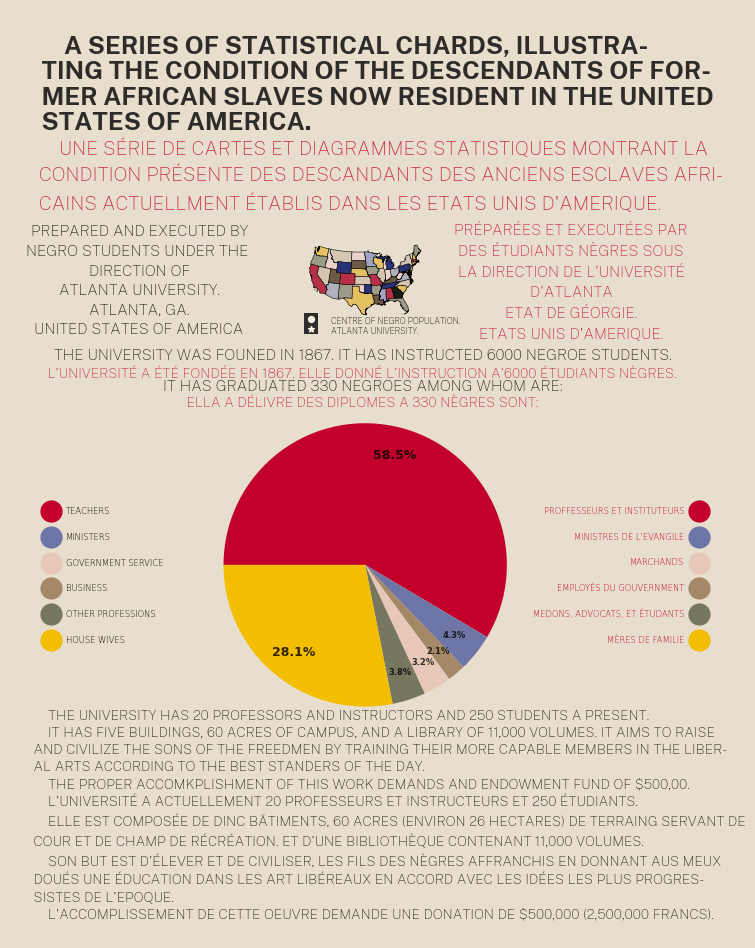

In [24]:
# Create figure
fig, ax = plt.subplots(figsize=(8, 10), facecolor=("#e8decd"))

### USA map
# Inset ax for USA map
usa_ax = ax.inset_axes([0.35, 0.75, 0.3, 0.1])

# Plot USA map
gdf_9311.plot(
    ax=usa_ax,
    color=gdf_9311["color"],   
    ec="black",
    lw=0.4
)

# Hide USA map axis
usa_ax.axis("off")

### USA labels
# Inset ax for labels
label_ax = ax.inset_axes([0.4, 0.728, 0.025, 0.03])

# Add a rectangle
my_rectangle = patches.Rectangle(
  xy=(0, 0),
  width=0.1,
  height=1,
  alpha=0.8,
  facecolor="black",    
)
label_ax.add_patch(my_rectangle)

# Add labels into rectangle
label_ax.scatter(0.05, 0.75, color="#f8f1e4", s=18)
label_ax.scatter(0.05, 0.25, color="#f8f1e4", marker="*", s=18)

# Hide label axis
label_ax.axis("off")

### USA Label texts
# Add labels to rectangle
fig.text(0.47, 0.682, s="CENTRE OF NEGRO POPULATION.", size=6, font=font_light)
fig.text(0.47, 0.672, s="ATLANTA UNIVERSITY.", size=6, font=font_light)

### USA map side texts
# Add texts next to USA map
fig.text(0.22, 0.725, s=usa_left, alpha=0.8, font=font_light, size=11, ha="center", va="center", linespacing=1.6)
fig.text(0.76, 0.725, s=usa_right, color="#c3002c", alpha=0.8, font=font_light, size=11, ha="center", va="center", linespacing=1.6)

#### Pie chart
# Inset ax for pie chart
pie_ax = ax.inset_axes([0, 0.2, 1, 0.46])

# Plot pie chart
wedges, texts, autotexts = pie_ax.pie(sorted_df["Percentage"], colors=sorted_df["color"], startangle=-180, counterclock=False, 
                                      labels=None, autopct="%1.1f%%", pctdistance=0.8, textprops={"fontsize":6, "alpha":0.8, "weight":"bold"})

# Update fontsize at index 0 and 5
for i, wedge in enumerate(wedges):
    if i in [0,5]:        
        autotexts[i].set_fontsize(9)

### Legends
# Custom circle markers for the legend
handles = [Line2D([], [], marker="o", linewidth=0.2, color=row["color"], label=row["Occupation"].upper(), markerfacecolor=row["color"], markersize=15)          
           for i, row in legend_df.iterrows()]

handles_FR = [Line2D([], [], marker="o", linewidth=0.2, color=row["color"], label=row["Occupation_FR"], markerfacecolor=row["color"], markersize=15)          
             for i, row in legend_df.iterrows()]

# Add legends
legend = fig.legend(handles=handles, bbox_to_anchor=(0.1, 0.43), loc="center left", 
                     labelspacing=2, fontsize=6, frameon = False)

legend_FR = fig.legend(handles=handles_FR, bbox_to_anchor=(0.95, 0.43), loc="center right", markerfirst=False, 
                     labelspacing=2, fontsize=6, frameon = False)

# Update fontweight in legend
for text in legend.get_texts():     
    text.set_fontweight("light")   

for text in legend_FR.get_texts():    
    text.set_color("#c3002c")    
    text.set_fontweight("light") 

### Texts
# Add title, subtitle and other texts
fig.text(0.08, 0.85, s=title_black, alpha=0.8, font=font_bold, size=18)
fig.text(0.08, 0.77, s=title_red, color="#c3002c", alpha=0.8, font=font_light, size=14, linespacing=1.6)
fig.text(0.08, 0.07, s=bottom_text, alpha=0.8, font=font_light, size=10, linespacing=1.5)
fig.text(0.5, 0.6, s=subtitle_black, alpha=0.8, font=font_light, size=11, ha="center")
fig.text(0.5, 0.585, s=subtitle_red, color="#c3002c", alpha=0.8, font=font_light, size=10, ha="center")

# Hide axis
ax.axis("off")

plt.show()

#plt.savefig("plate37.jpg")

In [25]:
import matplotlib.image as mpimg
from PIL import Image
import numpy as np

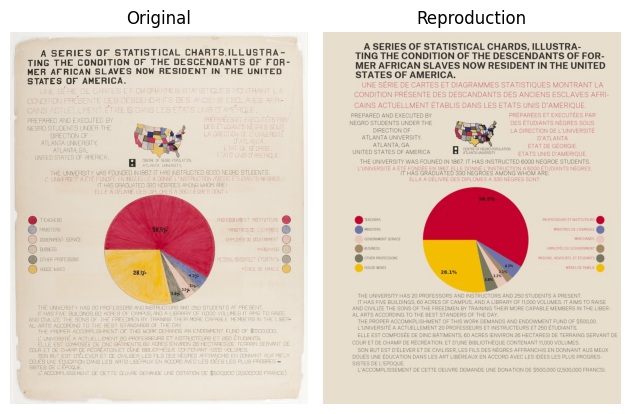

In [26]:
# Load images 
image1 = Image.open("original-plate-37.jpg")
image2 = Image.open("plate37.jpg")

# Convert to numpy arrays
images = [np.array(image1), np.array(image2)]
titles = ["Original", "Reproduction"]

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2)

# Loop through axes, images, and titles
for ax, img, title in zip(axes, images, titles):
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(title)

# Adjust the layout and show
plt.tight_layout()
plt.show()

# Save the combined figure 
#plt.savefig("plate37sidebyside.png", dpi=300)